# Task 2: Predict Future Stock Prices (Short-Term)

This notebook demonstrates how to use historical stock data to predict the next day's closing price using regression models. We will fetch data from Yahoo Finance, prepare features, train a model, and compare predictions to actual values.

## 1. Import Required Libraries
Import pandas, numpy, yfinance, matplotlib, seaborn, and scikit-learn for data handling, fetching, modeling, and visualization.

In [3]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

sns.set(style="whitegrid")

## 2. Select Stock and Load Historical Data
Select a stock (e.g., Apple: AAPL) and load historical data using the yfinance library.

In [4]:
# Select stock symbol and load data
stock_symbol = 'AAPL'  # Apple Inc.

data = yf.download(stock_symbol, period='2y', interval='1d')

# Display the first few rows
data.head()

C:\Users\zaidm\AppData\Local\Temp\ipykernel_14596\1162230512.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(stock_symbol, period='2y', interval='1d')
[*********************100%***********************]  1 of 1 completed



Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2023-06-26,183.433411,186.185851,183.393799,184.977944,48088700
2023-06-27,186.195755,186.522486,183.829448,184.047268,50730800
2023-06-28,187.373962,188.017513,185.740325,186.067040,51216800
2023-06-29,187.710571,188.185824,187.067021,187.205632,46347300
2023-06-30,192.047180,192.552119,189.364038,189.730380,85069600


## 3. Prepare Features and Target
Use Open, High, Low, and Volume to predict the next day's Close price.

In [5]:
# Prepare features and target
data = data.dropna()
data['Next_Close'] = data['Close'].shift(-1)

features = ['Open', 'High', 'Low', 'Volume']
X = data[features][:-1]  # Exclude last row (no next close)
y = data['Next_Close'][:-1]

# Display the prepared features and target
X.head(), y.head()

(Price             Open        High         Low    Volume
 Ticker            AAPL        AAPL        AAPL      AAPL
 Date                                                    
 2023-06-26  184.977944  186.185851  183.393799  48088700
 2023-06-27  184.047268  186.522486  183.829448  50730800
 2023-06-28  186.067040  188.017513  185.740325  51216800
 2023-06-29  187.205632  188.185824  187.067021  46347300
 2023-06-30  189.730380  192.552119  189.364038  85069600,
 Date
 2023-06-26    186.195755
 2023-06-27    187.373962
 2023-06-28    187.710571
 2023-06-29    192.047180
 2023-06-30    190.552139
 Name: Next_Close, dtype: float64)

## 4. Train Regression Models
Split the data into training and testing sets, then train a Linear Regression and a Random Forest model.

In [6]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Train Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Train Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Evaluate models
print('Linear Regression RMSE:', np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print('Random Forest RMSE:', np.sqrt(mean_squared_error(y_test, y_pred_rf)))

Linear Regression RMSE: 5.586476418661251
Random Forest RMSE: 7.588494838309513


## 5. Plot Actual vs Predicted Closing Prices
Visualize and compare the actual and predicted closing prices for the test set.

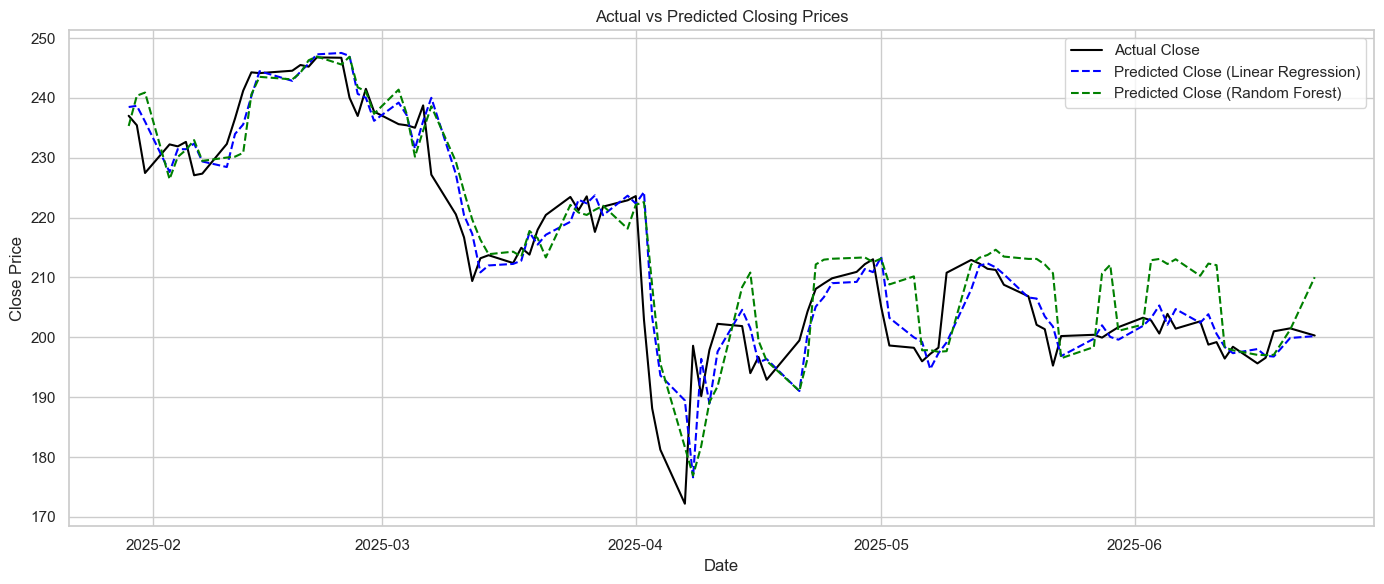

In [7]:
# Plot actual vs predicted closing prices
plt.figure(figsize=(14, 6))
plt.plot(y_test.index, y_test, label='Actual Close', color='black')
plt.plot(y_test.index, y_pred_lr, label='Predicted Close (Linear Regression)', linestyle='--', color='blue')
plt.plot(y_test.index, y_pred_rf, label='Predicted Close (Random Forest)', linestyle='--', color='green')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title('Actual vs Predicted Closing Prices')
plt.legend()
plt.tight_layout()
plt.show()